In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import pysam
from tqdm import tqdm

## The distribution of ATAC peak length

In [2]:
peakDir = '/workdir/jz963/utils/plantcad2/results/accessible_regions/peaks'
fnames = os.listdir(peakDir)

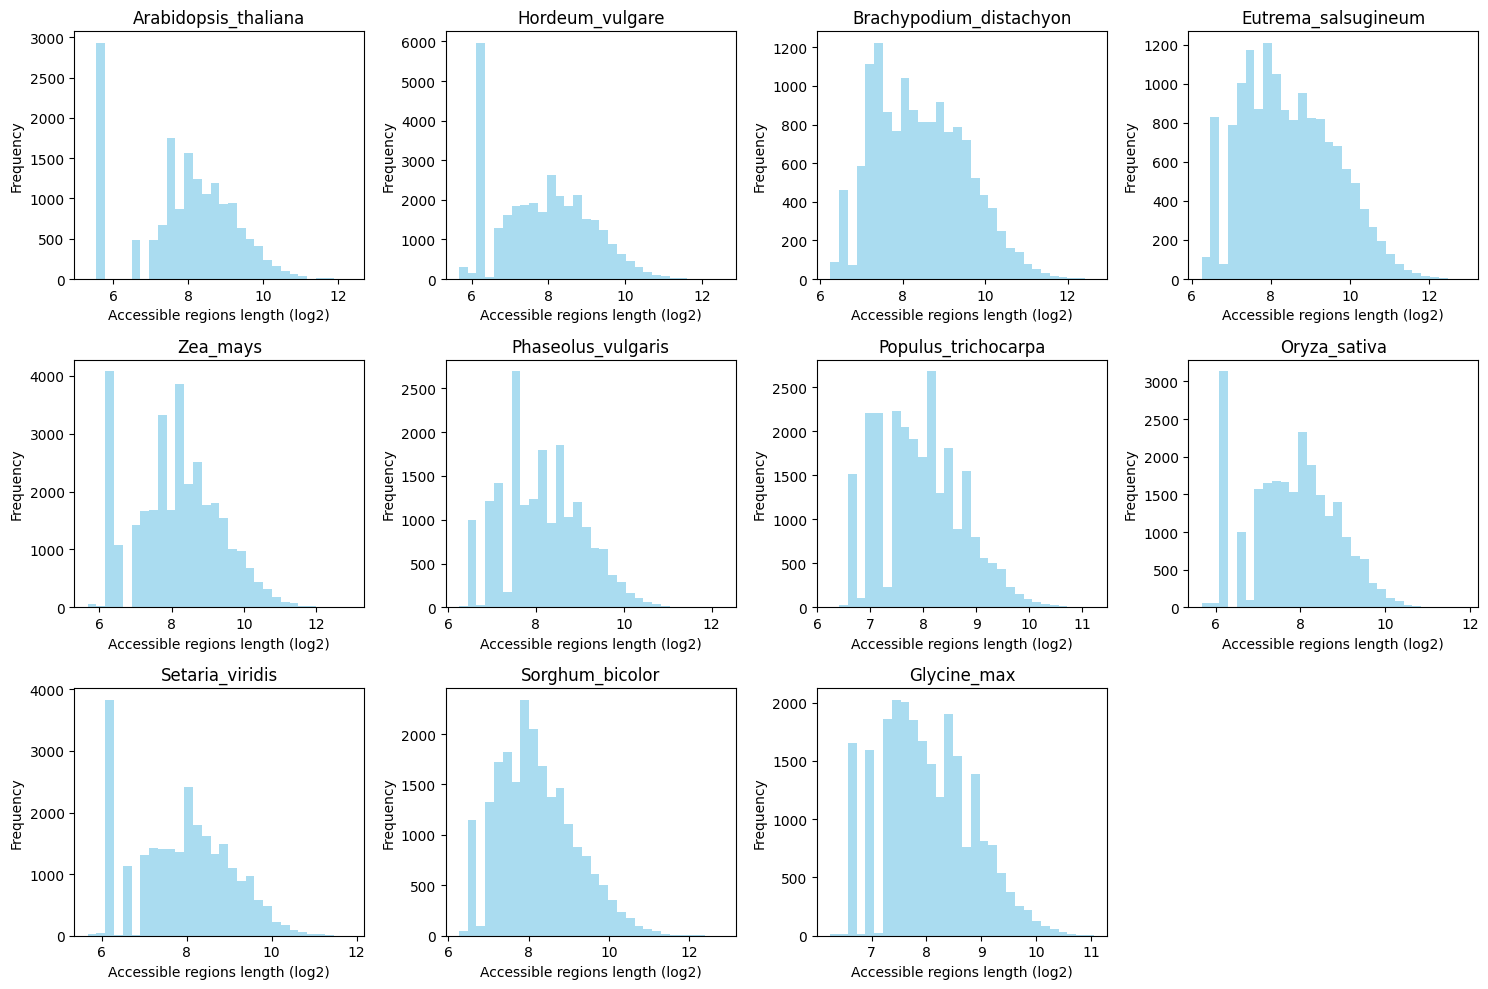

In [3]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5)
for i, fname in enumerate(fnames):
    plt.subplot(3, 4, i+1) 
    curBED = pd.read_csv(f'{peakDir}/{fname}', header=None, sep='\t')
    Len = np.log2(curBED[2] - curBED[1])
    plt.hist(Len, bins=30, alpha=0.7, color='skyblue')
    title = fname.replace('.bed', '')
    plt.title(f'{title}')
    plt.xlabel('Accessible regions length (log2)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
    

## Description

Data structure:
```
annotations
├── Arabidopsis_thaliana.gff3
├── Brachypodium_distachyon.gff3
├── Eutrema_salsugineum.gff3
├── Glycine_max.gff3
├── Hordeum_vulgare.gff3
├── Oryza_sativa.gff3
├── Phaseolus_vulgaris.gff3
├── Populus_trichocarpa.gff3
├── Setaria_viridis.gff3
├── Sorghum_bicolor.gff3
└── Zea_mays.gff3

genomes
├── Arabidopsis_thaliana.fa
├── Arabidopsis_thaliana.fa.fai
├── Brachypodium_distachyon.fa
├── Brachypodium_distachyon.fa.fai
├── Eutrema_salsugineum.fa
├── Eutrema_salsugineum.fa.fai
├── Glycine_max.fa
├── Glycine_max.fa.fai
├── Hordeum_vulgare.fa
├── Hordeum_vulgare.fa.fai
├── Oryza_sativa.fa
├── Oryza_sativa.fa.fai
├── Phaseolus_vulgaris.fa
├── Phaseolus_vulgaris.fa.fai
├── Populus_trichocarpa.fa
├── Populus_trichocarpa.fa.fai
├── Setaria_viridis.fa
├── Setaria_viridis.fa.fai
├── Sorghum_bicolor.fa
├── Sorghum_bicolor.fa.fai
├── Zea_mays.fa
└── Zea_mays.fa.fai

peaks
├── Arabidopsis_thaliana.bed
├── Brachypodium_distachyon.bed
├── Eutrema_salsugineum.bed
├── Glycine_max.bed
├── Hordeum_vulgare.bed
├── Oryza_sativa.bed
├── Phaseolus_vulgaris.bed
├── Populus_trichocarpa.bed
├── Setaria_viridis.bed
├── Sorghum_bicolor.bed
└── Zea_mays.bed

```


We ran this task on three different context windows:
- 300bp
- 600bp
- 1kb

```bash
bash process.sh config_300bp.json
bash process.sh config_600bp.json
bash process.sh config_1000bp.json
```

In [4]:
dataDir = {'c300': '../../results/accessible_regions/tmp/data/acd9f64001bc1e4cd7a2b0d85d73f46f3ac82c7360cc9ce4e1cab0a50a023dd8.tsv',
           'c600': '../../results/accessible_regions/tmp/data/8a75ef68cf374487c5515b878607b28bcd354a91c3894176da43f2947f30560b.tsv',
           'c1000': '../../results/accessible_regions/tmp/data/77e194a0196def7a6a25653f147593f40adb7b233ce527e40b24e0c552d04e18.tsv'}

In [ ]:
for context in dataDir.keys():
    outputDir = f'../../results/PlantCAD2_tasks/accessible_angiosperm_{context}'
    os.makedirs(outputDir, exist_ok=True)
    dataPath = dataDir[context]
    data = pd.read_csv(dataPath, sep='\t', header=None, 
                      dtype={0: str, 1: int, 2: int, 3: int, 4: str, 5: str})
    
    data.columns = ['Chr', 'Start', 'End', 'Label', 'Type', 'Species']
    ath = data[data['Species'] == 'Arabidopsis thaliana'].copy()
    rest = data[data['Species'] != 'Arabidopsis thaliana'].copy()
    # get fasta sequences for ath
    genome = pysam.FastaFile('../../results/accessible_regions/genomes/Arabidopsis_thaliana.fa')
    seq = []
    for _, row in tqdm(ath.iterrows(), total=len(ath), desc="Extracting sequences for ath"):
        chrom, start, end = row['Chr'], row['Start'], row['End']
        curseq = genome.fetch(reference=chrom, start=start, end=end)
        seq.append(curseq)
    ath['Seq'] = seq
    ath = ath[['Chr', 'Start', 'End', 'Type', 'Species', 'Seq', 'Label']]
    train = ath[ath['Chr'] != 'chr5'].copy()
    valid = ath[ath['Chr'] == 'chr5'].copy()
    train.to_csv(f'{outputDir}/train.tsv', sep='\t', index=False)
    valid.to_csv(f'{outputDir}/valid.tsv', sep='\t', index=False)
    

    for species in rest['Species'].unique():
        curData = rest[rest['Species'] == species].copy()
        prefix = species.replace(' ', '_')
        genome = pysam.FastaFile(f'../../results/accessible_regions/genomes/{prefix}.fa')
        seq = []
        for _, row in tqdm(curData.iterrows(), total=len(curData), desc=f'Extracting sequences for {prefix}'):
            chrom, start, end = row['Chr'], row['Start'], row['End']
            curseq = genome.fetch(reference=str(chrom), start=start, end=end)
            seq.append(curseq)
        curData['Seq'] = seq
        curData = curData[['Chr', 'Start', 'End', 'Type', 'Species', 'Seq', 'Label']]
        curData.to_csv(f'{outputDir}/test_{prefix.lower()}.tsv', sep='\t', index=False)
        print(prefix, (curData['Label'] == 1).sum(), (curData['Label'] == 0).sum())